In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split

In [4]:
#create a Model class that inherits the nn.Module
class Model(nn.Module):
    # Iput layer (4 features of the flower) -->
    # Hidden layer1 (number of neurons) -->
    # Hidden Layer2 (number of neurons) -->
    # Output (3 Classes of iris flowers)
    def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
        super().__init__() # instantiate our nn.Nodule
        self.fc1 = nn.Linear(in_features, h1)
        self.fc2 = nn.Linear(h1, h2)
        #self.fc3 = nn.Linear(h2, h3)
        self.out = nn.Linear(h2, out_features)

    # we have got our basic model set up and we need to create a function that
    # moves everything forward
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # relu function stands for rectified linear unit basically says ok do
        # something and then if the output of that something less than zero
        # let's just call it zero otherwise use the output so if it's more than
        # zero use whatever number that is
        # x = F.relu(self.fc3(x)) #  let's
        x = self.out(x)

        return x

In [5]:
# Pick a manual seed for randomization
#torch.manual_seed(32)
torch.manual_seed(21)
# Create an instance of model
model = Model()

In [6]:
# now we need to read the data of iris fowers
# https://gist.github.com/curran/a08a1080b88344b0c8a7
# df = pd.read_csv('Iris.csv')
url = ('https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv')
my_df = pd.read_csv(url)
my_df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [7]:
# Change last column from strings to integers
my_df['species'] = my_df['species'].replace('setosa', 0)
my_df['species'] = my_df['species'].replace('versicolor', 1)
my_df['species'] = my_df['species'].replace('virginica', 2)
my_df

/var/folders/4t/z4mmsykn2r79sjvsdpjg0qr80000gn/T/ipykernel_8111/1521296644.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace('virginica', 2)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [8]:
# Train Test Split!  Set X, y
X = my_df.drop('species', axis=1)
y = my_df['species']
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
# Train Test Split
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=32)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

In [11]:
# Convert X features to float tensors
X_train = torch.FloatTensor(X_train.values)
X_test = torch.FloatTensor(X_test.values)

# Convert y labels to tensors long
y_train = torch.LongTensor(y_train.values)
y_test = torch.LongTensor(y_test.values)

In [12]:
# Set the criterion of model to measure the error, how far off the predictions are from the data
criterion = nn.CrossEntropyLoss()
# Choose Adam Optimizer, lr = learning rate (if error doesn't go down after a bunch of iterations
# (epochs), lower our learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
# Train our model!
# Epochs? (one run thru all the training data in our network)
epochs = 100
losses = []
for i in range(epochs):
  # Go forward and get a prediction
  y_pred = model.forward(X_train) # Get predicted results

  # Measure the loss/error, gonna be high at first
  loss = criterion(y_pred, y_train) # predicted values vs the y_train

  # Keep Track of our losses
  losses.append(loss.detach().numpy())

  # print every 10 epoch
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  # Do some back propagation: take the error rate of forward propagation and feed it back
  # thru the network to fine tune the weights
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.1224557161331177
Epoch: 10 and loss: 0.9070497155189514
Epoch: 20 and loss: 0.581246554851532
Epoch: 30 and loss: 0.37704232335090637
Epoch: 40 and loss: 0.23056380450725555
Epoch: 50 and loss: 0.1303471326828003
Epoch: 60 and loss: 0.08161325752735138
Epoch: 70 and loss: 0.059959523379802704
Epoch: 80 and loss: 0.04872286692261696
Epoch: 90 and loss: 0.04171000048518181


Text(0.5, 0, 'Epoch')

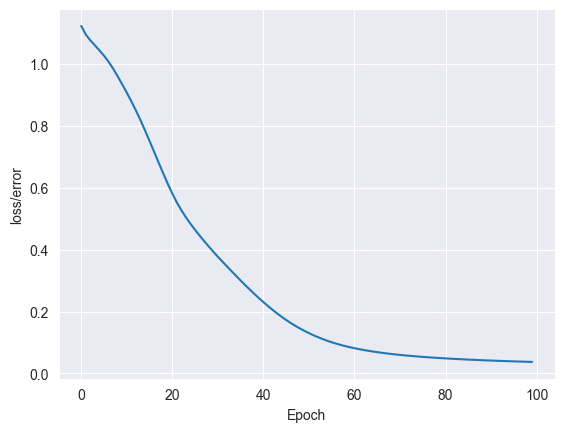

In [15]:
# Graph it out!
plt.plot(range(epochs), losses)
plt.ylabel("loss/error")
plt.xlabel('Epoch')

In [14]:
# Evaluate Model on Test Data Set (validate model on test set)
with torch.no_grad():  # Basically turn off back propogation
  y_eval = model.forward(X_test) # X_test are features from our test set, y_eval will be predictions
  loss = criterion(y_eval, y_test) # Find the loss or error

loss

tensor(0.1380)

In [16]:
correct = 0
with torch.no_grad():
  for i, data in enumerate(X_test):
    y_val = model.forward(data)
    # Will tell us what type of flower class our network thinks it is
    print(f'{i+1}.)  {str(y_val)} \t {y_test[i]} \t {y_val.argmax().item()}')

    # Correct or not
    if y_val.argmax().item() == y_test[i]:
        correct +=1
print(f'We got {correct} correct!')

1.)  tensor([-0.2029,  6.9144, -0.8890]) 	 1 	 1
2.)  tensor([ 18.1766,  12.1600, -23.0988]) 	 0 	 0
3.)  tensor([ 18.8548,  12.3028, -23.7713]) 	 0 	 0
4.)  tensor([ 19.3305,  12.6007, -24.3605]) 	 0 	 0
5.)  tensor([-0.1505,  7.0392, -1.0021]) 	 1 	 1
6.)  tensor([-0.4166,  7.6728, -0.7020]) 	 1 	 1
7.)  tensor([ 19.2843,  12.6597, -24.3482]) 	 0 	 0
8.)  tensor([-8.8813,  4.3562,  9.6693]) 	 2 	 2
9.)  tensor([ 18.1402,  11.9542, -22.9336]) 	 0 	 0
10.)  tensor([ 19.6811,  12.8229, -24.7959]) 	 0 	 0
11.)  tensor([ 1.1646,  6.9765, -2.5194]) 	 1 	 1
12.)  tensor([-0.2602,  6.9027, -0.8491]) 	 1 	 1
13.)  tensor([-11.7171,   4.8199,  13.1423]) 	 2 	 2
14.)  tensor([-12.4059,   5.6151,  13.6690]) 	 2 	 2
15.)  tensor([ 17.1420,  11.5882, -21.7925]) 	 0 	 0
16.)  tensor([-5.1051,  6.4431,  4.9758]) 	 1 	 1
17.)  tensor([-5.8695,  5.6320,  5.9497]) 	 2 	 2
18.)  tensor([-2.9122,  6.5449,  2.3236]) 	 1 	 1
19.)  tensor([ 22.1457,  14.3849, -27.8563]) 	 0 	 0
20.)  tensor([-9.4358,  4.352

In [17]:
# now we use a new data with the model to predect which flower is it
new_iris = torch.tensor([4.8, 3.3, 1.4, 0.3])

with torch.no_grad():
    print(model(new_iris))

tensor([ 18.1598,  11.8695, -22.9110])


In [18]:
new_iris = torch.tensor([5.9, 3.0,	5.1, 1.8])

with torch.no_grad():
    print(model(new_iris))

tensor([-7.8010,  5.0370,  8.2777])
